<a href="https://colab.research.google.com/github/gabriela0402/ai-interview-evaluator/blob/main/notebooks/01_primeira_avaliacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Primeira avaliação de respostas em entrevistas

## Objetivo

Investigar como um modelo de linguagem avalia respostas escritas de entrevistas
comportamentais usando uma rubrica estruturada.

Neste experimento, o modelo avaliará cada resposta segundo os seguintes critérios:

- relevância;
- especificidade;
- comunicação;
- reflexão;
- resultado.

As avaliações geradas pela IA serão comparadas com uma referência inicial criada
manualmente, utilizando métricas como erro médio absoluto e correlação de Spearman.

> Este projeto tem finalidade educacional e experimental. As avaliações da IA não
> devem ser utilizadas sozinhas para tomar decisões reais de contratação.

## Dados

O experimento utiliza um dataset sintético com respostas para perguntas sobre:

- resolução de problemas;
- trabalho em equipe;
- organização.


In [ ]:
%pip install -q openai pandas pydantic python-dotenv scikit-learn matplotlib seaborn


In [ ]:
import re
import time
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print("Ambiente configurado com sucesso!")


Python: 3.13.15
Pandas: 2.2.3
Scikit-learn: 1.6.1
Ambiente configurado com sucesso!


In [ ]:
import pandas as pd

url_dataset = (
    "https://raw.githubusercontent.com/"
    "gabriela0402/ai-interview-evaluator/"
    "main/data/sample/entrevista_dataset_inicial.jsonl"
 )

dataset = pd.read_json(url_dataset, lines=True)

print(f"Dataset carregado com sucesso!")
print(f"Quantidade de respostas: {len(dataset)}")

dataset.head()


Dataset carregado com sucesso!
Quantidade de respostas: 9


,id,pergunta,competencia,resposta,nivel_esperado
0,resp_001,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Durante um trabalho em grupo, percebemos que o...",5
1,resp_002,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,Uma vez tive um problema em um trabalho e tent...,3
2,resp_003,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Já tive problemas antes, mas normalmente outra...",1
3,resp_004,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,"Em um projeto da faculdade, cada pessoa ficou ...",5
4,resp_005,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Já fiz trabalhos em grupo. Cada pessoa fez sua...,3


In [ ]:
print("Colunas:")
print(list(dataset.columns))

print("\nRespostas por competência:")
print(dataset["competencia"].value_counts())

print("\nNíveis esperados:")
print(sorted(dataset["nivel_esperado"].unique()))


Colunas:
['id', 'pergunta', 'competencia', 'resposta', 'nivel_esperado']

Respostas por competência:
competencia
resolucao_de_problemas    3
trabalho_em_equipe        3
organizacao               3
Name: count, dtype: int64

Níveis esperados:
[np.int64(1), np.int64(3), np.int64(5)]


In [ ]:
from google.colab import userdata
from openai import OpenAI

token_hf = userdata.get("HF_TOKEN")

if not token_hf:
    raise ValueError(
        "O segredo HF_TOKEN não foi encontrado nos Secrets do Colab."
    )

cliente_hf = OpenAI(
    api_key=token_hf,
    base_url="https://router.huggingface.co/v1"
 )

modelo_hf = "openai/gpt-oss-20b"

print("Cliente da Hugging Face configurado com sucesso!")


Cliente da Hugging Face configurado com sucesso!


In [ ]:
import requests

url_metricas = (
    "https://raw.githubusercontent.com/"
    "gabriela0402/ai-interview-evaluator/"
    "main/src/metricas.py"
 )

codigo_metricas = requests.get(url_metricas).text

with open("metricas.py", "w", encoding="utf-8") as arquivo:
    arquivo.write(codigo_metricas)

print("Módulo de métricas carregado com sucesso!")


Módulo de métricas carregado com sucesso!


In [ ]:
from metricas import extrair_nota, extrair_avaliacao

print("Funções de métricas importadas com sucesso!")


Funções de métricas importadas com sucesso!


In [40]:
from metricas import (
    adicionar_nota_geral_manual,
    adicionar_diferencas,
    calcular_correlacao_spearman
)

print("Funções de comparação importadas com sucesso!")


Funções de comparação importadas com sucesso!


In [ ]:
import requests

url_avaliador = (
    "https://raw.githubusercontent.com/"
    "gabriela0402/ai-interview-evaluator/"
    "main/src/avaliador.py"
 )

codigo_avaliador = requests.get(url_avaliador).text

with open("avaliador.py", "w", encoding="utf-8") as arquivo:
    arquivo.write(codigo_avaliador)

print("Módulo avaliador carregado com sucesso!")


Módulo avaliador carregado com sucesso!


In [ ]:
from avaliador import avaliar_resposta

print("Função avaliar_resposta importada com sucesso!")


Função avaliar_resposta importada com sucesso!


In [ ]:
import time

resultados = []

for indice, linha in dataset.iterrows():
    print(f"Avaliando resposta {indice + 1} de {len(dataset)}...")

    try:
        avaliacao = avaliar_resposta(
            linha,
            cliente_hf,
            modelo_hf
        )

        resultados.append({
            "id": linha["id"],
            "pergunta": linha["pergunta"],
            "competencia": linha["competencia"],
            "nivel_esperado": linha["nivel_esperado"],
            "avaliacao_modelo": avaliacao,
            "status": "sucesso"
        })

    except Exception as erro:
        resultados.append({
            "id": linha["id"],
            "pergunta": linha["pergunta"],
            "competencia": linha["competencia"],
            "nivel_esperado": linha["nivel_esperado"],
            "avaliacao_modelo": None,
            "status": f"erro: {erro}"
        })

    time.sleep(2)

resultados_df = pd.DataFrame(resultados)

print("Processamento concluído!")
display(resultados_df)


Avaliando resposta 1 de 9...
Avaliando resposta 2 de 9...
Avaliando resposta 3 de 9...
Avaliando resposta 4 de 9...
Avaliando resposta 5 de 9...
Avaliando resposta 6 de 9...
Avaliando resposta 7 de 9...
Avaliando resposta 8 de 9...
Avaliando resposta 9 de 9...
Processamento concluído!


,id,pergunta,competencia,nivel_esperado,avaliacao_modelo,status
0,resp_001,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,5,Relevância: 5 \nEspecificidade: 3 \nComunica...,sucesso
1,resp_002,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,3,Relevância: 3 \nEspecificidade: 1 \nComunica...,sucesso
2,resp_003,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,1,Relevância: 1 \nEspecificidade: 1 \nComunica...,sucesso
3,resp_004,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,5,Relevância: 5 \nEspecificidade: 2 \nComunica...,sucesso
4,resp_005,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,3,Relevância: 3 \nEspecificidade: 1 \nComunica...,sucesso
5,resp_006,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,1,Relevância: 1 \nEspecificidade: 1 \nComunica...,sucesso
6,resp_007,Como você lida com um prazo curto?,organizacao,5,Relevância: 4 \nEspecificidade: 3 \nComunica...,sucesso
7,resp_008,Como você lida com um prazo curto?,organizacao,3,Relevância: 4 \nEspecificidade: 2 \nComunica...,sucesso
8,resp_009,Como você lida com um prazo curto?,organizacao,1,Relevância: 2 \nEspecificidade: 1 \nComunica...,sucesso


In [ ]:
resultados_sucesso = resultados_df[
    resultados_df["status"] == "sucesso"
].copy()

print(f"Respostas avaliadas com sucesso: {len(resultados_sucesso)}")

display(
    resultados_sucesso[
        ["id", "competencia", "nivel_esperado", "avaliacao_modelo"]
    ]
)


Respostas avaliadas com sucesso: 9


,id,competencia,nivel_esperado,avaliacao_modelo
0,resp_001,resolucao_de_problemas,5,Relevância: 5 \nEspecificidade: 3 \nComunica...
1,resp_002,resolucao_de_problemas,3,Relevância: 3 \nEspecificidade: 1 \nComunica...
2,resp_003,resolucao_de_problemas,1,Relevância: 1 \nEspecificidade: 1 \nComunica...
3,resp_004,trabalho_em_equipe,5,Relevância: 5 \nEspecificidade: 2 \nComunica...
4,resp_005,trabalho_em_equipe,3,Relevância: 3 \nEspecificidade: 1 \nComunica...
5,resp_006,trabalho_em_equipe,1,Relevância: 1 \nEspecificidade: 1 \nComunica...
6,resp_007,organizacao,5,Relevância: 4 \nEspecificidade: 3 \nComunica...
7,resp_008,organizacao,3,Relevância: 4 \nEspecificidade: 2 \nComunica...
8,resp_009,organizacao,1,Relevância: 2 \nEspecificidade: 1 \nComunica...


In [39]:
notas_extraidas = resultados_sucesso[
    "avaliacao_modelo"
].apply(
    extrair_avaliacao
).apply(pd.Series)

resultados_analisaveis = pd.concat(
    [
        resultados_sucesso.reset_index(drop=True),
        notas_extraidas
    ],
    axis=1
)

display(
    resultados_analisaveis[
        [
            "id",
            "competencia",
            "nivel_esperado",
            "nota_relevancia",
            "nota_especificidade",
            "nota_comunicacao",
            "nota_reflexao",
            "nota_resultado",
            "nota_geral"
        ]
    ]
)


,id,competencia,nivel_esperado,nota_relevancia,nota_especificidade,nota_comunicacao,nota_reflexao,nota_resultado,nota_geral
0,resp_001,resolucao_de_problemas,5,5.0,3.0,4.0,2.0,3.0,3.4
1,resp_002,resolucao_de_problemas,3,3.0,1.0,3.0,1.0,2.0,2.0
2,resp_003,resolucao_de_problemas,1,1.0,1.0,3.0,1.0,1.0,1.2
3,resp_004,trabalho_em_equipe,5,5.0,2.0,4.0,1.0,2.0,3.0
4,resp_005,trabalho_em_equipe,3,3.0,1.0,3.0,1.0,1.0,2.0
5,resp_006,trabalho_em_equipe,1,1.0,1.0,2.0,1.0,1.0,1.2
6,resp_007,organizacao,5,4.0,3.0,4.0,3.0,2.0,3.0
7,resp_008,organizacao,3,4.0,2.0,4.0,1.0,1.0,2.5
8,resp_009,organizacao,1,2.0,1.0,2.0,1.0,1.0,1.5


In [ ]:
avaliacoes_manuais = resultados_sucesso[
    ["id", "pergunta", "competencia"]
].copy()

avaliacoes_manuais = avaliacoes_manuais.merge(
    dataset[["id", "resposta"]],
    on="id",
    how="left"
)

avaliacoes_manuais["nota_relevancia_manual"] = ""
avaliacoes_manuais["nota_especificidade_manual"] = ""
avaliacoes_manuais["nota_comunicacao_manual"] = ""
avaliacoes_manuais["nota_reflexao_manual"] = ""
avaliacoes_manuais["nota_resultado_manual"] = ""
avaliacoes_manuais["observacao_manual"] = ""

display(avaliacoes_manuais)


,id,pergunta,competencia,resposta,nota_relevancia_manual,nota_especificidade_manual,nota_comunicacao_manual,nota_reflexao_manual,nota_resultado_manual,observacao_manual
0,resp_001,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Durante um trabalho em grupo, percebemos que o...",,,,,,
1,resp_002,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,Uma vez tive um problema em um trabalho e tent...,,,,,,
2,resp_003,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Já tive problemas antes, mas normalmente outra...",,,,,,
3,resp_004,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,"Em um projeto da faculdade, cada pessoa ficou ...",,,,,,
4,resp_005,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Já fiz trabalhos em grupo. Cada pessoa fez sua...,,,,,,
5,resp_006,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Prefiro fazer trabalhos sozinho porque é mais ...,,,,,,
6,resp_007,Como você lida com um prazo curto?,organizacao,Primeiro verifico tudo o que precisa ser feito...,,,,,,
7,resp_008,Como você lida com um prazo curto?,organizacao,"Quando tenho pouco tempo, tento fazer as taref...",,,,,,
8,resp_009,Como você lida com um prazo curto?,organizacao,Faço tudo correndo e entrego o que conseguir.,,,,,,


In [ ]:
avaliacoes_referencia = {
    "resp_001": {
        "nota_relevancia_manual": 5,
        "nota_especificidade_manual": 5,
        "nota_comunicacao_manual": 5,
        "nota_reflexao_manual": 3,
        "nota_resultado_manual": 4,
        "observacao_manual": (
            "Apresenta contexto, ações concretas e resultado. "
            "Poderia explicar melhor o que aprendeu com a situação."
        )
    },
    "resp_002": {
        "nota_relevancia_manual": 4,
        "nota_especificidade_manual": 3,
        "nota_comunicacao_manual": 3,
        "nota_reflexao_manual": 2,
        "nota_resultado_manual": 2,
        "observacao_manual": (
            "Responde à pergunta, mas apresenta poucos detalhes e não explica "
            "claramente as ações nem o resultado."
        )
    },
    "resp_003": {
        "nota_relevancia_manual": 2,
        "nota_especificidade_manual": 1,
        "nota_comunicacao_manual": 3,
        "nota_reflexao_manual": 1,
        "nota_resultado_manual": 1,
        "observacao_manual": (
            "A resposta é curta e não apresenta uma situação concreta, ações "
            "realizadas ou resultado."
        )
    },
    "resp_004": {
        "nota_relevancia_manual": 5,
        "nota_especificidade_manual": 5,
        "nota_comunicacao_manual": 5,
        "nota_reflexao_manual": 3,
        "nota_resultado_manual": 4,
        "observacao_manual": (
            "Demonstra colaboração, organização e apoio a um colega. "
            "Apresenta um resultado, mas poderia detalhar melhor o aprendizado."
        )
    },
    "resp_005": {
        "nota_relevancia_manual": 4,
        "nota_especificidade_manual": 2,
        "nota_comunicacao_manual": 4,
        "nota_reflexao_manual": 2,
        "nota_resultado_manual": 3,
        "observacao_manual": (
            "Responde ao tema, mas é genérica e não deixa claro qual foi a "
            "contribuição individual do candidato."
        )
    },
    "resp_006": {
        "nota_relevancia_manual": 2,
        "nota_especificidade_manual": 1,
        "nota_comunicacao_manual": 3,
        "nota_reflexao_manual": 1,
        "nota_resultado_manual": 1,
        "observacao_manual": (
            "Não apresenta um exemplo de trabalho em equipe e demonstra "
            "preferência por trabalhar sozinho."
        )
    },
    "resp_007": {
        "nota_relevancia_manual": 5,
        "nota_especificidade_manual": 4,
        "nota_comunicacao_manual": 5,
        "nota_reflexao_manual": 4,
        "nota_resultado_manual": 4,
        "observacao_manual": (
            "Apresenta uma estratégia clara de priorização e comunicação de riscos. "
            "Poderia incluir um exemplo real para fortalecer a resposta."
        )
    }
}

for id_resposta, avaliacao in avaliacoes_referencia.items():
    for coluna, valor in avaliacao.items():
        avaliacoes_manuais.loc[
            avaliacoes_manuais["id"] == id_resposta,
            coluna
        ] = valor

display(avaliacoes_manuais)


,id,pergunta,competencia,resposta,nota_relevancia_manual,nota_especificidade_manual,nota_comunicacao_manual,nota_reflexao_manual,nota_resultado_manual,observacao_manual
0,resp_001,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Durante um trabalho em grupo, percebemos que o...",5,5,5,3,4,"Apresenta contexto, ações concretas e resultad..."
1,resp_002,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,Uma vez tive um problema em um trabalho e tent...,4,3,3,2,2,"Responde à pergunta, mas apresenta poucos deta..."
2,resp_003,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Já tive problemas antes, mas normalmente outra...",2,1,3,1,1,A resposta é curta e não apresenta uma situaçã...
3,resp_004,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,"Em um projeto da faculdade, cada pessoa ficou ...",5,5,5,3,4,"Demonstra colaboração, organização e apoio a u..."
4,resp_005,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Já fiz trabalhos em grupo. Cada pessoa fez sua...,4,2,4,2,3,"Responde ao tema, mas é genérica e não deixa c..."
5,resp_006,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Prefiro fazer trabalhos sozinho porque é mais ...,2,1,3,1,1,Não apresenta um exemplo de trabalho em equipe...
6,resp_007,Como você lida com um prazo curto?,organizacao,Primeiro verifico tudo o que precisa ser feito...,5,4,5,4,4,Apresenta uma estratégia clara de priorização ...
7,resp_008,Como você lida com um prazo curto?,organizacao,"Quando tenho pouco tempo, tento fazer as taref...",,,,,,
8,resp_009,Como você lida com um prazo curto?,organizacao,Faço tudo correndo e entrego o que conseguir.,,,,,,


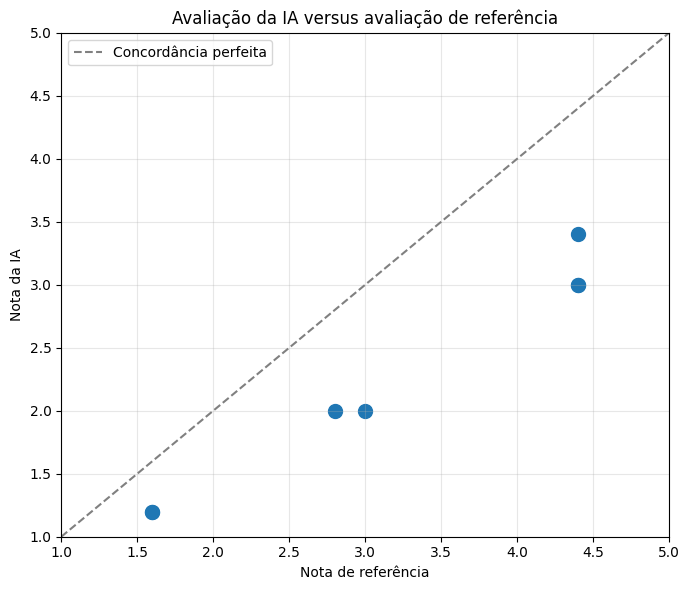

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    comparacao_notas["nota_geral_manual"],
    comparacao_notas["nota_geral"],
    s=100
)

plt.plot(
    [1, 5],
    [1, 5],
    linestyle="--",
    color="gray",
    label="Concordância perfeita"
)

plt.title("Avaliação da IA versus avaliação de referência")
plt.xlabel("Nota de referência")
plt.ylabel("Nota da IA")
plt.xlim(1, 5)
plt.ylim(1, 5)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "grafico_ia_vs_referencia.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [ ]:
comparacao_notas.to_csv(
    "comparacao_ia_referencia.csv",
    index=False,
    encoding="utf-8-sig"
)

resumo_metricas.to_csv(
    "resumo_metricas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos de análise criados:")
print("- comparacao_ia_referencia.csv")
print("- resumo_metricas.csv")
print("- grafico_ia_vs_referencia.png")


Arquivos de análise criados:
- comparacao_ia_referencia.csv
- resumo_metricas.csv
- grafico_ia_vs_referencia.png


In [ ]:
comparacao_notas = adicionar_diferencas(
    comparacao_notas
)

display(
    comparacao_notas[
        [
            "id",
            "nota_geral",
            "nota_geral_manual",
            "diferenca_ia_referencia",
            "erro_absoluto"
        ]
    ]
)


,id,nota_geral,nota_geral_manual,diferenca_ia_referencia,erro_absoluto
0,resp_001,3.4,4.4,-1.0,1.0
1,resp_002,2.0,2.8,-0.8,0.8
2,resp_003,1.2,1.6,-0.4,0.4
3,resp_004,3.0,4.4,-1.4,1.4
4,resp_005,2.0,3.0,-1.0,1.0
5,resp_006,1.2,1.6,-0.4,0.4
6,resp_007,3.0,4.4,-1.4,1.4
7,resp_008,2.5,NaN,NaN,NaN
8,resp_009,1.5,NaN,NaN,NaN


In [ ]:
correlacao_spearman = calcular_correlacao_spearman(
    comparacao_notas
)

print(
    f"Correlação de Spearman: "
    f"{correlacao_spearman:.2f}"
)


Correlação de Spearman: 0.96


In [ ]:
total_respostas = len(dataset)

total_sucesso = (
    resultados_df["status"] == "sucesso"
).sum()

total_erros = total_respostas - total_sucesso

erro_medio_comparacao = (
    comparacao_notas["erro_absoluto"].mean()
)

diferenca_media_comparacao = (
    comparacao_notas["diferenca_ia_referencia"].mean()
)

print(f"Respostas processadas: {total_respostas}")
print(f"Respostas avaliadas com sucesso: {total_sucesso}")
print(f"Respostas com erro: {total_erros}")


Respostas processadas: 9
Respostas avaliadas com sucesso: 9
Respostas com erro: 0


In [41]:
colunas_manuais = [
    "nota_relevancia_manual",
    "nota_especificidade_manual",
    "nota_comunicacao_manual",
    "nota_reflexao_manual",
    "nota_resultado_manual"
]

comparacao_notas = adicionar_nota_geral_manual(
    comparacao_notas,
    colunas_manuais
)

display(
    comparacao_notas[
        ["id", "nota_geral", "nota_geral_manual"]
    ]
)


,id,nota_geral,nota_geral_manual
0,resp_001,3.4,4.4
1,resp_002,2.0,2.8
2,resp_003,1.2,1.6
3,resp_004,3.0,4.4
4,resp_005,2.0,3.0
5,resp_006,1.2,1.6
6,resp_007,3.0,4.4
7,resp_008,2.5,NaN
8,resp_009,1.5,NaN


In [ ]:
colunas_manuais = [
    "nota_relevancia_manual",
    "nota_especificidade_manual",
    "nota_comunicacao_manual",
    "nota_reflexao_manual",
    "nota_resultado_manual"
]

comparacao_notas = adicionar_nota_geral_manual(
    comparacao_notas,
    colunas_manuais
)

display(
    comparacao_notas[
        ["id", "nota_geral", "nota_geral_manual"]
    ]
)


,id,nota_geral,nota_geral_manual
0,resp_001,3.4,4.4
1,resp_002,2.0,2.8
2,resp_003,1.2,1.6
3,resp_004,3.0,4.4
4,resp_005,2.0,3.0
5,resp_006,1.2,1.6
6,resp_007,3.0,4.4
7,resp_008,2.5,NaN
8,resp_009,1.5,NaN


In [42]:
comparacao_notas = adicionar_diferencas(
    comparacao_notas
)

display(
    comparacao_notas[
        [
            "id",
            "nota_geral",
            "nota_geral_manual",
            "diferenca_ia_referencia",
            "erro_absoluto"
        ]
    ]
)


,id,nota_geral,nota_geral_manual,diferenca_ia_referencia,erro_absoluto
0,resp_001,3.4,4.4,-1.0,1.0
1,resp_002,2.0,2.8,-0.8,0.8
2,resp_003,1.2,1.6,-0.4,0.4
3,resp_004,3.0,4.4,-1.4,1.4
4,resp_005,2.0,3.0,-1.0,1.0
5,resp_006,1.2,1.6,-0.4,0.4
6,resp_007,3.0,4.4,-1.4,1.4
7,resp_008,2.5,NaN,NaN,NaN
8,resp_009,1.5,NaN,NaN,NaN


In [43]:
correlacao_spearman = calcular_correlacao_spearman(
    comparacao_notas
)

print(
    f"Correlação de Spearman: "
    f"{correlacao_spearman:.2f}"
)


Correlação de Spearman: 0.96


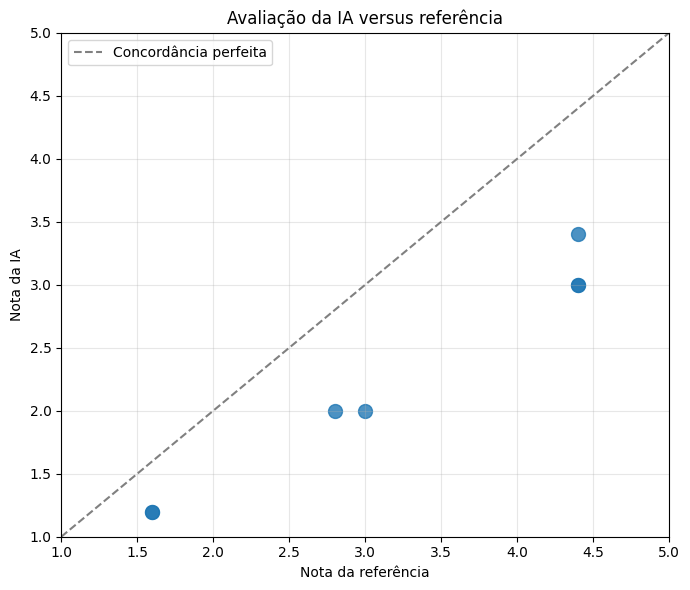

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    comparacao_notas["nota_geral_manual"],
    comparacao_notas["nota_geral"],
    s=100,
    alpha=0.8
)

plt.plot(
    [1, 5],
    [1, 5],
    linestyle="--",
    color="gray",
    label="Concordância perfeita"
)

plt.title("Avaliação da IA versus referência")
plt.xlabel("Nota da referência")
plt.ylabel("Nota da IA")
plt.xlim(1, 5)
plt.ylim(1, 5)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "grafico_ia_vs_referencia.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


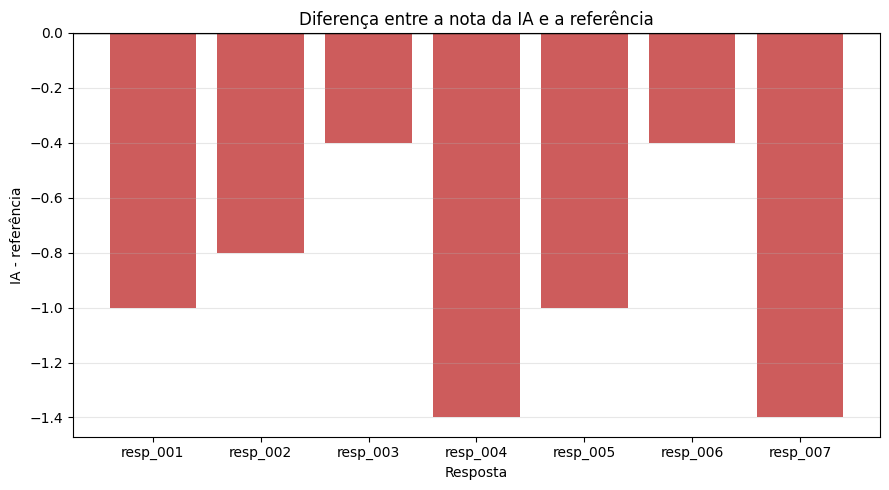

In [45]:
plt.figure(figsize=(9, 5))

cores = [
    "seagreen" if valor >= 0 else "indianred"
    for valor in comparacao_notas["diferenca_ia_referencia"]
]

plt.bar(
    comparacao_notas["id"],
    comparacao_notas["diferenca_ia_referencia"],
    color=cores
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.title("Diferença entre a nota da IA e a referência")
plt.xlabel("Resposta")
plt.ylabel("IA - referência")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "grafico_diferenca_ia_referencia.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


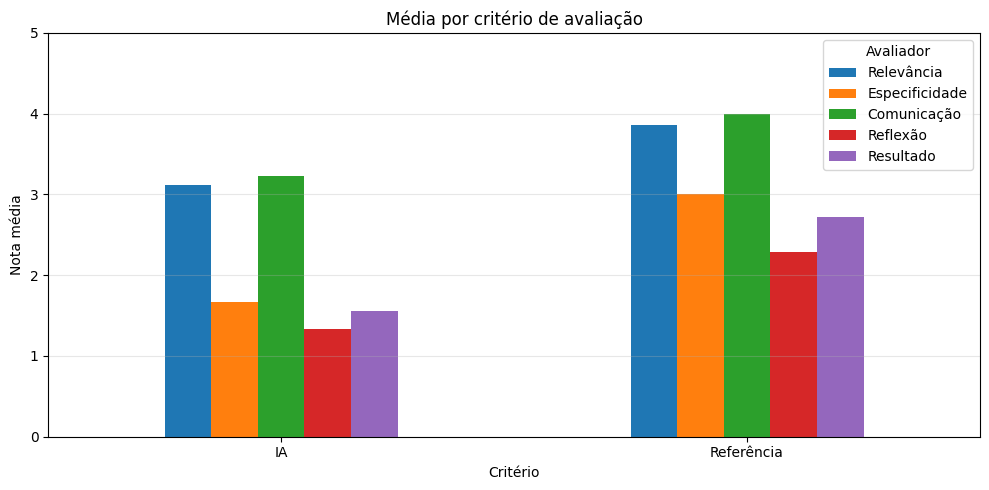

In [46]:
criterios_grafico = {
    "Relevância": (
        "nota_relevancia",
        "nota_relevancia_manual"
    ),
    "Especificidade": (
        "nota_especificidade",
        "nota_especificidade_manual"
    ),
    "Comunicação": (
        "nota_comunicacao",
        "nota_comunicacao_manual"
    ),
    "Reflexão": (
        "nota_reflexao",
        "nota_reflexao_manual"
    ),
    "Resultado": (
        "nota_resultado",
        "nota_resultado_manual"
    )
}

medias_criterios = pd.DataFrame({
    criterio: {
        "IA": comparacao_notas[coluna_ia].mean(),
        "Referência": comparacao_notas[coluna_referencia].mean()
    }
    for criterio, (coluna_ia, coluna_referencia)
    in criterios_grafico.items()
})

medias_criterios.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Média por critério de avaliação")
plt.xlabel("Critério")
plt.ylabel("Nota média")
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Avaliador")
plt.tight_layout()

plt.savefig(
    "grafico_medias_por_criterio.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [47]:
comparacao_notas.to_csv(
    "comparacao_ia_referencia.csv",
    index=False,
    encoding="utf-8-sig"
)

medias_criterios.to_csv(
    "medias_por_criterio.csv",
    encoding="utf-8-sig"
)

print("Tabelas e gráficos gerados com sucesso.")


Tabelas e gráficos gerados com sucesso.


In [49]:
total_respostas = len(dataset)

total_sucesso = (
    resultados_df["status"] == "sucesso"
).sum()

total_erros = total_respostas - total_sucesso

erro_medio_comparacao = (
    comparacao_notas["erro_absoluto"].mean()
)

diferenca_media_comparacao = (
    comparacao_notas["diferenca_ia_referencia"].mean()
)

relatorio_atualizado = f"""
# Relatório do primeiro experimento

## Objetivo

Avaliar respostas de entrevistas comportamentais utilizando um modelo de linguagem
e comparar suas avaliações com uma referência criada manualmente.

## Resultados

- Respostas processadas: {total_respostas}
- Respostas avaliadas com sucesso: {total_sucesso}
- Respostas não avaliadas: {total_erros}
- Respostas comparáveis: {len(comparacao_notas)}
- Correlação de Spearman: {correlacao_spearman:.2f}
- Erro médio absoluto: {erro_medio_comparacao:.2f}
- Diferença média entre IA e referência: {diferenca_media_comparacao:.2f}

## Limitação da API

Duas respostas não puderam ser avaliadas porque os créditos gratuitos da
Hugging Face foram esgotados durante o processamento. A API retornou o erro HTTP 402.

Por isso, os resultados são parciais e devem ser interpretados apenas como
uma análise exploratória.

## Limitações metodológicas

- O dataset é pequeno e sintético.
- A avaliação de referência foi criada para este experimento.
- Não houve um grupo amplo de avaliadores humanos.
- Apenas um modelo foi utilizado.
- Os resultados não devem ser usados sozinhos para decisões reais de contratação.

## Próximos passos

- Criar um experimento de consistência.
- Investigar possíveis vieses.
- Usar saída estruturada em JSON.
- Testar uma alternativa local gratuita.
"""

with open(
    "relatorio_primeiro_experimento.md",
    "w",
    encoding="utf-8"
) as arquivo:
    arquivo.write(relatorio_atualizado)

print("Relatório criado com sucesso.")


Relatório criado com sucesso.


In [ ]:
from google.colab import files

files.download("relatorio_primeiro_experimento.md")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>